# Dimensionality reduction: PCA and MDS on neural data

**NS5007 Human and Artificial Intelligence · lab notebook**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/qihongl/NS5007/blob/main/pca_mds.ipynb)

Neural recordings are high-dimensional: hundreds of voxels or thousands of neurons, each one a dimension. The structure of interest — *what* the brain represents — typically occupies far fewer dimensions than that. In this lab we build two classical tools for recovering it:

- **PCA** (Principal Component Analysis) rotates the data onto its axes of maximal variance.
- **MDS** (Multi-Dimensional Scaling) takes only a matrix of pairwise distances and places every item on a 2D map that respects them.

We start with synthetic examples and then apply both methods to two real datasets:

1. **IT cortex responses to 92 everyday images**, human fMRI + monkey single-cell ([Kriegeskorte et al., 2008](https://doi.org/10.1016/j.neuron.2008.10.043)) — the data set that launched representational similarity analysis (RSA).
2. **Hippocampal fMRI during sequences with temporal community structure** ([Schapiro et al., 2013](https://doi.org/10.1038/nn.3331)) — data from [OpenNeuro ds001621](https://openneuro.org/datasets/ds001621), preprocessed offline (despiking, motion correction, normalization) and packaged per region; `make_week5_derived_data.py` documents every step. Note that the 2013 searchlight effects are cortical; we include hippocampus and visual cortex as control regions.

**Learning goals.** After this lab you can (i) run PCA and read scree plots and projections, (ii) build an RDM and embed it with MDS, (iii) state when one method is preferable to the other, and (iv) go from raw BIDS fMRI to an embedding of stimulus codes.

About 5–10 minutes end-to-end on Colab — the fMRI preprocessing was done offline and the packaged pattern data (~15 MB, `data/`) loads instantly. All exercises have solutions hidden at the bottom.

> **Colab:** open with the badge above (notebook + data live in the course GitHub repo), or upload the notebook and the `data/` folder manually. The §5 cell fetches the packaged fMRI patterns automatically.


In [1]:
import os, sys, time, importlib.util, subprocess, urllib.request

for mod_name, pip_name in [('numpy', 'numpy'), ('scipy', 'scipy'),
                           ('matplotlib', 'matplotlib'), ('pandas', 'pandas'),
                           ('sklearn', 'scikit-learn')]:
    if importlib.util.find_spec(mod_name) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pip_name])

import numpy as np
import pandas as pd
import scipy.io as sio
from scipy.spatial.distance import squareform, pdist
from scipy.stats import spearmanr, rankdata, ttest_1samp
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.decomposition import PCA
from sklearn.manifold import MDS, Isomap

np.random.seed(42)
mpl.rcParams['figure.dpi'] = 110

DATA_DIR = 'data'
os.makedirs(DATA_DIR, exist_ok=True)

def run_mds(D, precomputed=False, seed=42):
    '''2-D MDS with pinned settings. Every MDS call goes through here so the
    pending scikit-learn API change (the `dissimilarity` kwarg is deprecated,
    removal slated for 1.10) is a one-line migration, and no FutureWarnings spam
    the output for students.'''
    import warnings
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', category=FutureWarning)
        return MDS(n_components=2,
                   dissimilarity='precomputed' if precomputed else 'euclidean',
                   n_init=4, random_state=seed,
                   normalized_stress='auto').fit_transform(D)

def fetch(url, dest):
    '''Download url -> dest, skip if already there.'''
    if os.path.exists(dest):
        print(f'cached: {dest}')
        return dest
    t0 = time.time()
    with urllib.request.urlopen(url) as r, open(dest, 'wb') as f:
        while True:
            chunk = r.read(1 << 22)
            if not chunk:
                break
            f.write(chunk)
    print(f'downloaded {dest} ({os.path.getsize(dest)/1e6:.1f} MB, {time.time()-t0:.0f}s)')
    return dest

rng = np.random.default_rng(42)
COMMUNITY_COLOR = {'A': '#4C72B0', 'B': '#DD8452', 'C': '#55A868'}

def plot_embedding(xy, labels, title='', ax=None):
    '''Scatter an embedding colored by community letter; boundary nodes get black rings.'''
    ax = ax or plt.gca()
    for lab, (x, y) in zip(labels, xy):
        c = COMMUNITY_COLOR[lab[0]]
        edge = 'k' if lab[1] in ('1', '5') else c      # boundary nodes end in 1 or 5
        ax.scatter(x, y, s=90, color=c, edgecolor=edge, linewidth=2.6, zorder=3)
        ax.annotate(lab, (x, y), textcoords='offset points',
                    xytext=(7, 4), fontsize=9, zorder=4)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])
    return ax

print('ready')


ready


## 1. Why reduce dimensions?

A recording session yields a data matrix: rows are conditions or stimuli, columns are features (voxels, neurons, pixels). With 674 neurons, each image corresponds to a point in a 674-dimensional space — impossible to inspect directly. Dimensionality reduction addresses two complementary questions:

- *Which directions in feature space carry the most signal?* — PCA
- *How far apart are the conditions?* — MDS

Both return a low-dimensional representation that can be plotted and interpreted.


## 2. Example 1 — three clusters hidden in 10 dimensions

We construct three clusters whose signal lies in a 2D plane, embedded in 10 dimensions with additional noise in all 10. We then apply PCA and check whether it recovers the plane.

The algorithm is straightforward: center the data, compute the eigenvectors of the covariance matrix ordered by eigenvalue, and project the data onto the top eigenvectors. Each eigenvalue equals the variance along its eigenvector.


In [2]:
def make_blobs(n_per=60, n_dims=10, seed=42):
    rng = np.random.default_rng(seed)
    centers = np.array([[0., 0.], [6., 3.], [-2., 7.]])       # separated on a plane
    pts2d = np.repeat(centers, n_per, axis=0) \
            + rng.normal(scale=1.0, size=(n_per*3, 2))
    W = rng.normal(size=(2, n_dims))                           # random mixing matrix
    X = pts2d @ W + rng.normal(scale=1.5, size=(n_per*3, n_dims))
    y = np.repeat([0, 1, 2], n_per)
    return X, y

X_blob, y_blob = make_blobs()
CLS_COLORS = ['#4C72B0', '#DD8452', '#55A868']
print(X_blob.shape, '<- (samples, features)')

(180, 10) <- (samples, features)


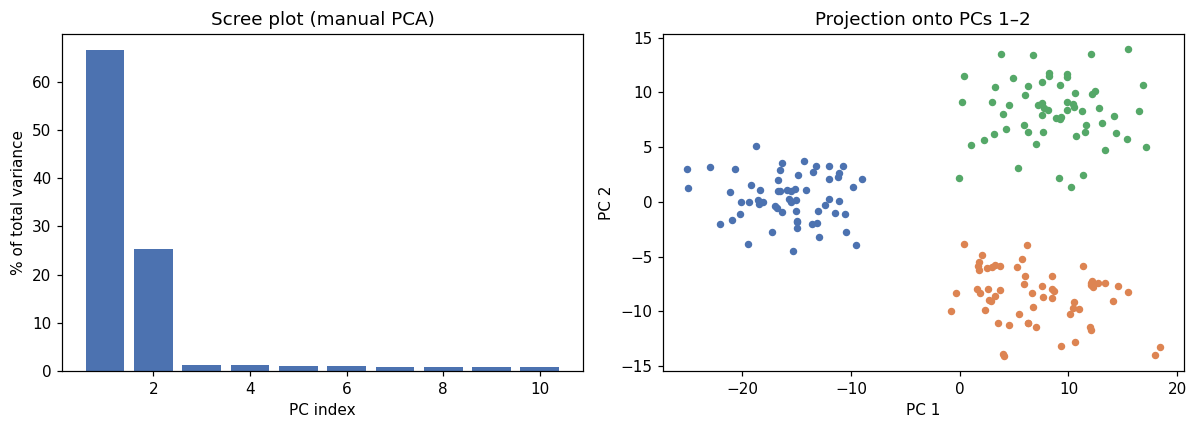

In [3]:
# --- PCA step by step -------------------------------------------------
X_c   = X_blob - X_blob.mean(axis=0)          # 1. center
C     = np.cov(X_c, rowvar=False)             # 2. covariance
eigval, eigvec = np.linalg.eigh(C)            # 3. eigendecomposition
order = np.argsort(eigval)[::-1]              # eigh sorts ascending -> flip
eigval, eigvec = eigval[order], eigvec[:, order]

scores = X_c @ eigvec                         # PC scores = projected data

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(np.arange(1, 11), eigval / eigval.sum() * 100, color='#4C72B0')
axes[0].set(xlabel='PC index', ylabel='% of total variance',
            title='Scree plot (manual PCA)')
for k in range(3):
    sel = y_blob == k
    axes[1].scatter(scores[sel, 0], scores[sel, 1], s=15, color=CLS_COLORS[k])
axes[1].set(xlabel='PC 1', ylabel='PC 2', title='Projection onto PCs 1–2')
plt.tight_layout();

The variance drops sharply after PC 2: the data are approximately two-dimensional, and PCA recovered that plane from the data alone. The same computation with scikit-learn, plus a cumulative-variance plot:


manual vs sklearn eigenvalues agree? True


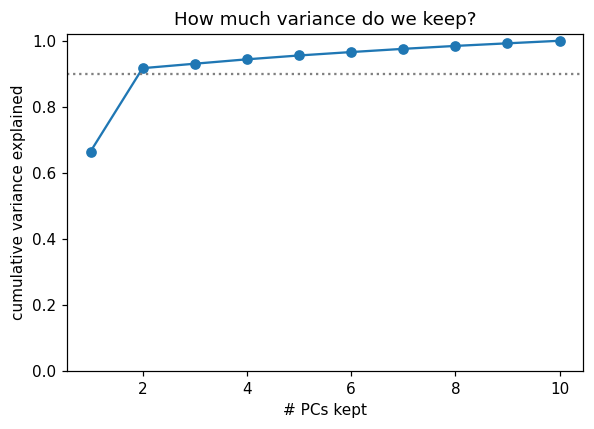

In [4]:
pca = PCA(n_components=10).fit(X_blob)        # sklearn centers internally
check = pca.explained_variance_ - eigval
print('manual vs sklearn eigenvalues agree?', np.allclose(check, 0))

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.plot(np.arange(1, 11), pca.explained_variance_ratio_.cumsum(), 'o-')
ax.set(xlabel='# PCs kept', ylabel='cumulative variance explained',
       title='How much variance do we keep?')
ax.axhline(0.9, ls=':', c='gray'); ax.set_ylim(0, 1.02)
plt.tight_layout();

### Exercise 1

(a) What fraction of the total variance do the first two PCs capture? Fill in one line below.

(b) PCA's axes are determined only up to sign and rotation within the recovered plane — PC 1 need not align with the original latent directions. The geometry is preserved nonetheless: verify that pairwise distances between samples are essentially unchanged after projecting onto the first 2 PCs.


In [5]:
var_first_two = None    # TODO (a): fraction of total variance in PCs 1+2
                        # hint: pca.explained_variance_ratio_ is a vector of fractions

pcs_2d    = None        # TODO (b): first two columns of the projection
D_before  = pdist(X_blob)
if var_first_two is None or pcs_2d is None:
    print('(fill the TODOs above, then rerun this cell)')
else:
    D_after = pdist(pcs_2d)
    print(f'first two PCs capture {var_first_two:.1%} of variance | '
          f'distance agreement r = {np.corrcoef(D_before, D_after)[0,1]:.3f}')

(fill the TODOs above, then rerun this cell)


## 3. Example 2 — a rolled sheet: where linear projection fails

PCA finds linear axes of maximal variance. On a curved surface this has a specific failure mode: a linear projection flattens the surface and can place distant parts on top of one another. To demonstrate, we construct a rolled sheet — a 2-D surface curled into about two turns — and compare methods.


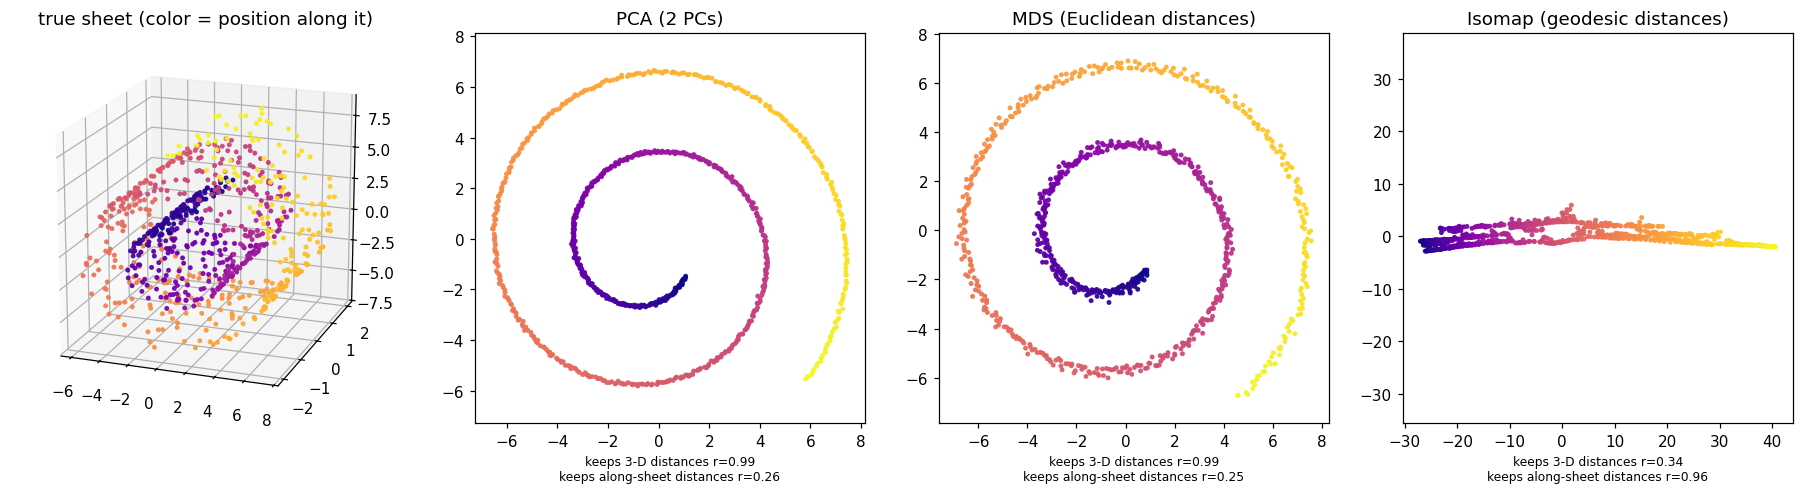

In [6]:
# a rolled-up sheet: a 2-D sheet curled into a roll, living in 3-D
n_points = 800   # <- number of points on the sheet. Increase for a denser, clearer
                 #    roll (and slower MDS); decrease for speed.

rng_roll = np.random.default_rng(42)
t = np.linspace(np.pi/2, np.pi/2 + 4*np.pi, n_points)   # position along the sheet (~2 turns)
r = 1.0 + 0.5 * t                                        # coil radius -> two visible turns
v = rng_roll.uniform(-2.0, 2.0, n_points)                # width of the sheet
X_roll = np.c_[r * np.cos(t), v, r * np.sin(t)]
X_roll += rng_roll.normal(scale=0.03, size=X_roll.shape) # measurement noise

D_along = pdist(np.c_[t, np.zeros_like(t)])              # distance measured ALONG the sheet

pca2     = PCA(2).fit_transform(X_roll)
emb_euc  = run_mds(X_roll)                               # MDS on Euclidean distances
iso_roll = Isomap(n_components=2).fit_transform(X_roll)  # MDS on geodesic distances

fig = plt.figure(figsize=(16.5, 4.6))
ax = fig.add_subplot(141, projection='3d')
ax.scatter(*X_roll.T, c=t, cmap='plasma', s=5, alpha=0.9)
ax.view_init(elev=18, azim=-70); ax.set_box_aspect((1, 1.1, 1))
ax.set_title('true sheet (color = position along it)')

panels = [(pca2, 'PCA (2 PCs)'),
          (emb_euc, 'MDS (Euclidean distances)'),
          (iso_roll, 'Isomap (geodesic distances)')]
for k, (E, ttl) in enumerate(panels):
    plt.subplot(1, 4, k + 2)
    plt.scatter(E[:, 0], E[:, 1], c=t, cmap='plasma', s=5, alpha=0.9)
    plt.title(ttl); plt.axis('equal')
    r3  = np.corrcoef(pdist(E), pdist(X_roll))[0, 1]
    ral = np.corrcoef(pdist(E), D_along)[0, 1]
    plt.xlabel(f'keeps 3-D distances r={r3:.2f}\nkeeps along-sheet distances r={ral:.2f}',
               fontsize=8)
plt.tight_layout();


The r-values printed under each panel summarize the result. PCA and Euclidean-distance MDS both reproduce the sheet's 3-D distances almost perfectly (r ≈ 1.0) — and both destroy the geometry of interest, the distances *along* the sheet (r ≈ 0.26): the two turns of the roll are superimposed. This is not a failure of MDS; the closed-form derivation below shows that on Euclidean distances classical MDS *is* PCA. No method can preserve Euclidean distances better than Euclidean geometry permits; the way forward is to change *which* distances are preserved. Isomap replaces straight-line distances with geodesic distances along the sheet and unrolls it (r ≈ 0.96).

Note MDS's input: only a matrix of pairwise distances — never the raw data. This is precisely the representation neuroscience often works with: rather than trusting individual neurons or voxels, we quantify *how similar* two activity patterns are. The matrix of pairwise dissimilarities between conditions is called the **representational dissimilarity matrix (RDM)**. The choice of distance used to build it is itself a modelling decision.


### Classical MDS, by hand

Classical (Torgerson) MDS has a closed-form solution, which is instructive to see once:
1. Square the distance matrix: $\mathbf{D}$ → $\mathbf{D}^{\circ 2}$.
2. Double-center it: $\mathbf{B} = -\tfrac{1}{2}\mathbf{J}\mathbf{D}^{\circ 2}\mathbf{J}$ with $\mathbf{J}=\mathbf{I}-\frac{1}{n}\mathbf{1}\mathbf{1}^\top$. $\mathbf{B}$ is the Gram matrix (inner products) of the centered points.
3. Take the top eigenvectors of $\mathbf{B}$, scaled by $\sqrt{\lambda}$.

For Euclidean distances this provably equals PCA — different machinery, same geometry — which is exactly why the two middle panels folded the roll identically.


In [7]:
def classical_mds(D, k=2):
    '''Classical MDS from a square distance matrix -> k-D coordinates.'''
    D2 = D ** 2
    n = D.shape[0]
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ D2 @ J                     # double-centered Gram matrix
    lam, V = np.linalg.eigh(B)
    top = np.argsort(lam)[::-1][:k]
    return V[:, top] * np.sqrt(np.clip(lam[top], 0, None))  # clip: non-Euclidean RDMs can give small negative eigenvalues

# check ours on the rolled sheet
D_roll = squareform(pdist(X_roll))
own  = classical_mds(D_roll, 2)
pca2 = PCA(2).fit_transform(X_roll)
skl  = run_mds(D_roll, precomputed=True, seed=1)   # sklearn's iterative SMACOF variant
for other, name in [(pca2, 'PCA'), (skl, 'sklearn SMACOF')]:
    r_pairs = [round(float(abs(np.corrcoef(own[:, i], other[:, j])[0, 1])), 2)
               for i in range(2) for j in range(2)]
    print(f'classical MDS vs {name} (rotation/reflection allowed):', r_pairs)
# PCA matches exactly (the cell-13 theorem). SMACOF lands near but not at the
# classical solution: it minimizes raw stress, a slightly different criterion --
# a reminder that "MDS" names a family of methods, not one algorithm.


classical MDS vs PCA (rotation/reflection allowed): [1.0, 0.0, 0.0, 1.0]
classical MDS vs sklearn SMACOF (rotation/reflection allowed): [0.78, 0.68, 0.62, 0.73]


## 4. Real data I — human and monkey IT: Kriegeskorte et al. 2008

We now apply these tools to real neural data. Kriegeskorte and colleagues presented the same 92 photographs — faces, bodies, houses, tools, fruits — while recording from human IT cortex (fMRI) and monkey IT (674 single neurons). For each image they considered the *response pattern*: the vector of activity across voxels or neurons. Their summary statistic was the correlation distance between each pair of images, assembled into a 92×92 RDM — displayed, in their figures, using each RDM's own percentile ranks rather than raw values (discussed below).

This approach became **representational similarity analysis (RSA)**, and it starts where §3 ended: distances first, geometry second.

The official supplement is mirrored in the [rsatoolbox repository](https://github.com/rsagroup/rsatoolbox/tree/master/demos/92imageData) (data © Kriegeskorte et al., shared for research/teaching).


In [8]:
K_URL = ('https://raw.githubusercontent.com/rsagroup/rsatoolbox/master/'
         'demos/92imageData/')
KG_DIR = os.path.join(DATA_DIR, 'kriegeskorte92')
os.makedirs(KG_DIR, exist_ok=True)

sup_mat  = fetch(K_URL + 'Kriegeskorte_Neuron2008_supplementalData.mat',
                 os.path.join(KG_DIR, 'supplemental.mat'))
brain_mat = fetch(K_URL + '92_brainRDMs.mat', os.path.join(KG_DIR, 'brainRDMs.mat'))
model_mat = fetch(K_URL + '92_modelRDMs.mat', os.path.join(KG_DIR, 'modelRDMs.mat'))

cached: data/kriegeskorte92/supplemental.mat
cached: data/kriegeskorte92/brainRDMs.mat
cached: data/kriegeskorte92/modelRDMs.mat


In [9]:
sup      = sio.loadmat(sup_mat)
brain    = sio.loadmat(brain_mat)
models_raw = sio.loadmat(model_mat)

images   = [st['image'] for st in sup['stimuli_92objs'][0]]         # the 92 photos
cat_str  = [str(np.squeeze(st['category'])) for st in sup['stimuli_92objs'][0]]
cat_lbls = [str(np.squeeze(c)) for c in sup['categoryLabels'][0]]
cat_vec  = sup['categoryVectors'].astype(bool)                      # 92 x 12 indicators
print('category labels:', cat_lbls)

# human IT: average the four subjects x two sessions
hIT_rdm = np.mean([brain['RDMs'][0, i, j]['RDM']
                   for i in range(4) for j in range(2)], axis=0).astype(float)

# monkey IT: stored as condensed upper triangle (C(92,2)=4186 pairs)
iu  = np.triu_indices(92, 1)
mit_condensed = np.squeeze(sup['RDMs_mIT_hIT_fig1'][0][0]['RDM']).astype(float)
mIT_rdm = np.zeros((92, 92)); mIT_rdm[iu] = mit_condensed; mIT_rdm += mIT_rdm.T

model_rdms = {str(m['name'][0]): np.asarray(m['RDM'], dtype=float)
              for m in models_raw['Models'][0]}
print('hIT', hIT_rdm.shape, '| mIT reconstructed:', mIT_rdm.shape,
      '| models:', list(model_rdms)[:4], '...')

category labels: ['animate', 'inanim', 'human', 'nonhumani', 'body', 'face', 'natObj', 'artiObj', 'rand24', 'rand48', 'other48', 'monkeyape']
hIT (92, 92) | mIT reconstructed: (92, 92) | models: ['animacy', 'FaceBodyManmadeNatobj', 'monkeyIT', 'EVA'] ...


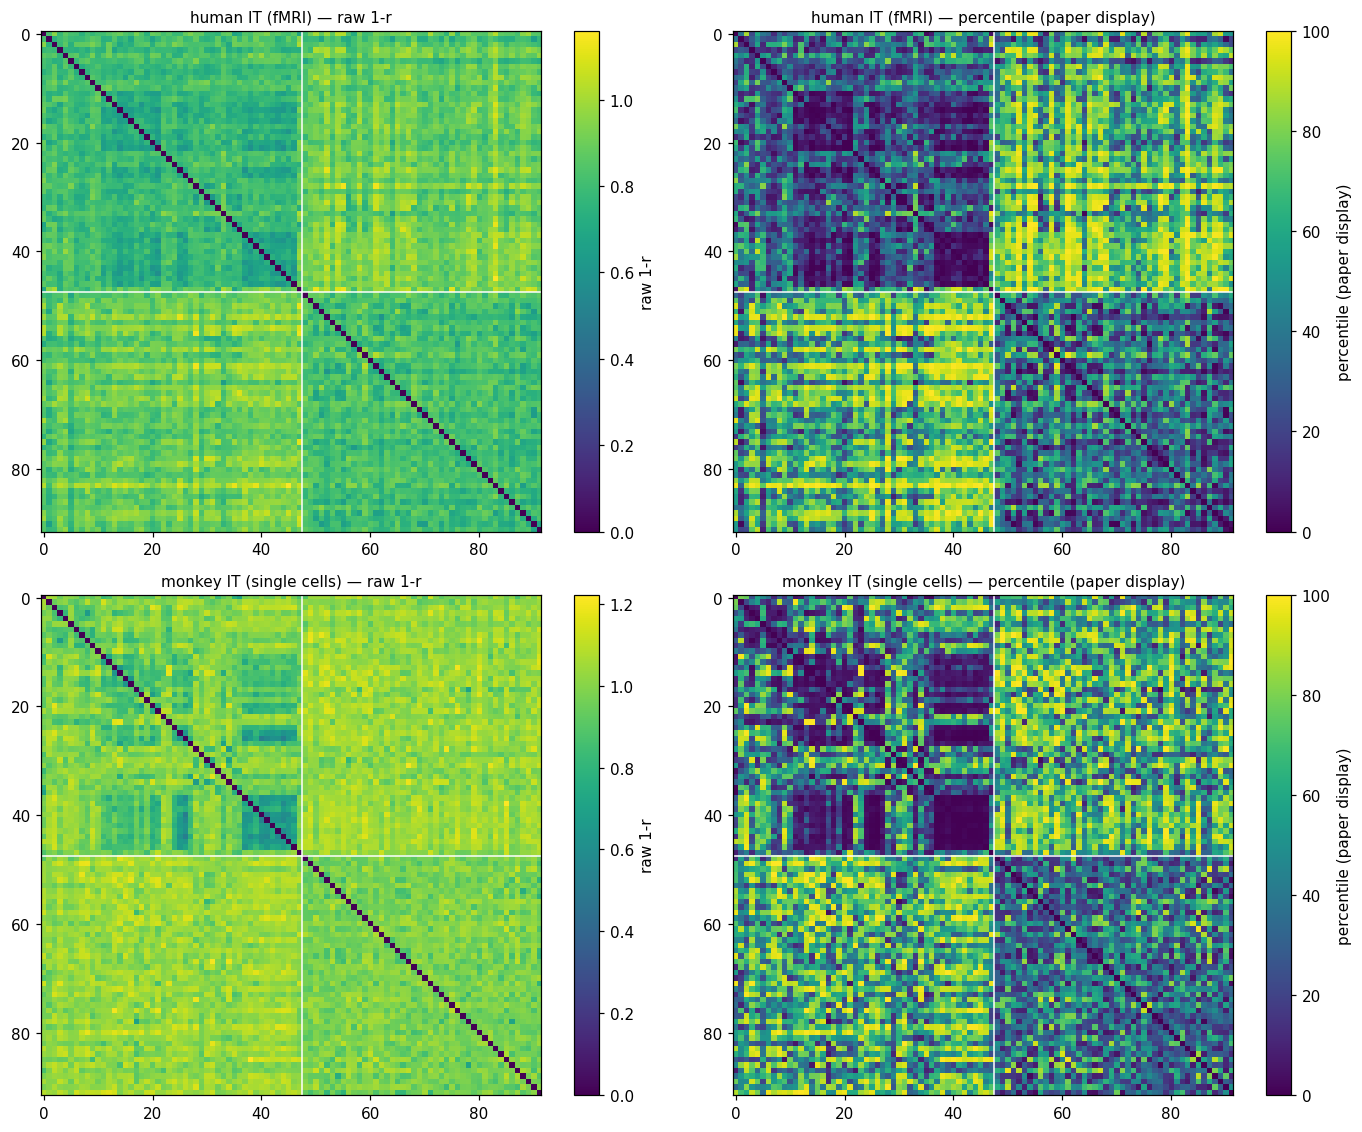

In [10]:
# --- display choice matters: the paper color-codes each RDM by percentiles ---
# Kriegeskorte et al. 2008 (Figs 1 & 5): "The color code reflects percentiles
# (see color bar) computed separately for each RDM". Mapping each RDM's 1-r
# values onto its own rank scale stretches the display across the full colormap,
# which makes the animate-inanimate block contrast look crisper than the raw
# values alone would. Statistics and MDS below still use the raw 1-r values --
# in the paper too, percentiles were a display-only transformation.
def percentile_rdm(rdm):
    '''Each dissimilarity -> its percentile among that RDM's upper-triangle values (0-100).'''
    p = rankdata(rdm[iu]) / len(iu[0]) * 100
    P = np.zeros_like(rdm)
    P[iu] = p
    P += P.T
    return P

sort_idx = np.argsort(cat_vec.argmax(axis=1))

fig, axes = plt.subplots(2, 2, figsize=(13, 10.4))
for row, (ttl, rdm) in enumerate([('human IT (fMRI)', hIT_rdm),
                                  ('monkey IT (single cells)', mIT_rdm)]):
    for col, (M, clab) in enumerate([(rdm, 'raw 1-r'),
                                     (percentile_rdm(rdm), 'percentile (paper display)')]):
        ax = axes[row, col]
        im = ax.imshow(M[np.ix_(sort_idx, sort_idx)], cmap='viridis')
        cat_of_sorted = cat_vec.argmax(axis=1)[sort_idx]
        for b in np.where(np.diff(cat_of_sorted) != 0)[0] + 0.5:
            ax.axvline(b, color='w', lw=1); ax.axhline(b, color='w', lw=1)
        ax.set_title(f'{ttl} — {clab}', fontsize=10)
        cb = plt.colorbar(im, ax=ax, fraction=.046); cb.set_label(clab)
plt.tight_layout();

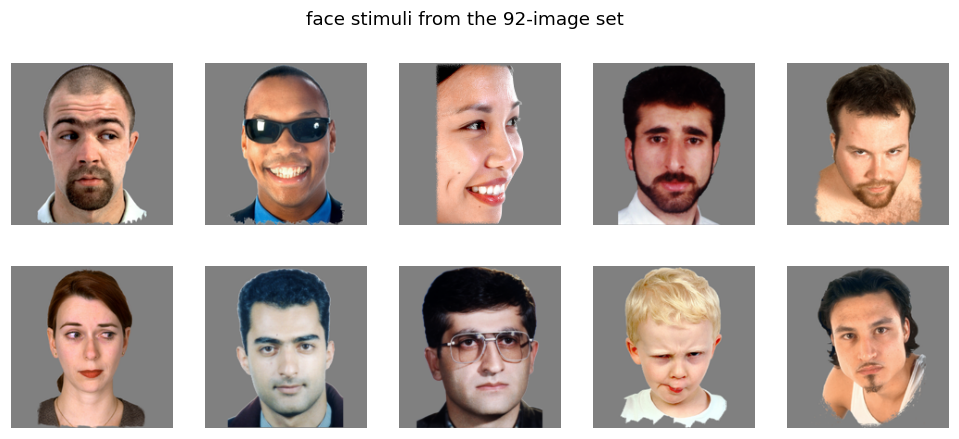

In [11]:
# a sample of the actual stimuli behind these matrices
face_ids = np.where(cat_vec[:, cat_lbls.index('face')])[0][:10]
fig, axes = plt.subplots(2, 5, figsize=(11, 4.4))
for ax, i in zip(axes.ravel(), face_ids):
    ax.imshow(images[i]); ax.axis('off')
fig.suptitle('face stimuli from the 92-image set');

Blocks of high dissimilarity appear at matching positions in the two species' matrices; this correspondence is the central claim of the paper. We quantify it below.

**A note on the display.** In the right-hand column, each RDM is color-coded by *within-RDM percentiles*, as in the paper (their Figure 1/5 legends: *"The color code reflects percentiles … computed separately for each RDM"*). Percentiles are uniform by construction, so this stretches the display across the full colormap range and exaggerates the apparent contrast of the animate–inanimate block structure; the raw 1 − r distributions (their Figs. 3A/6) are positively skewed. The transformation is display-only — the paper's MDS and statistics use raw 1 − r values, as does every analysis below.


### Exercise 2 — do faces stick together?

`rdm_within_between` (above) computes the mean RDM entry among same-category vs. different-category image pairs. Apply it to the human-IT RDM with the face mask defined above: fill in `within_f` and `between_f`, then interpret the result. Are faces more similar to each other than to other images? What would the two values be if category membership carried no information?


In [12]:
def rdm_within_between(rdm, mask_bool):
    '''Mean dissimilarity among same-group vs cross-group image pairs.'''
    a = rdm[iu]; same = mask_bool[iu[0]] == mask_bool[iu[1]]
    return a[same].mean(), a[~same].mean()

mask_face  = cat_vec[:, cat_lbls.index('face')]
within_f   = None   # TODO: fill with the first output of rdm_within_between(...)
between_f  = None   # TODO: ...and the second output
if within_f is None:
    print('(complete both TODOs, then rerun)')
else:
    print(f'within-faces: {within_f:.3f} | faces vs rest: {between_f:.3f}')

(complete both TODOs, then rerun)


### From RDMs to maps — MDS embeddings of both species

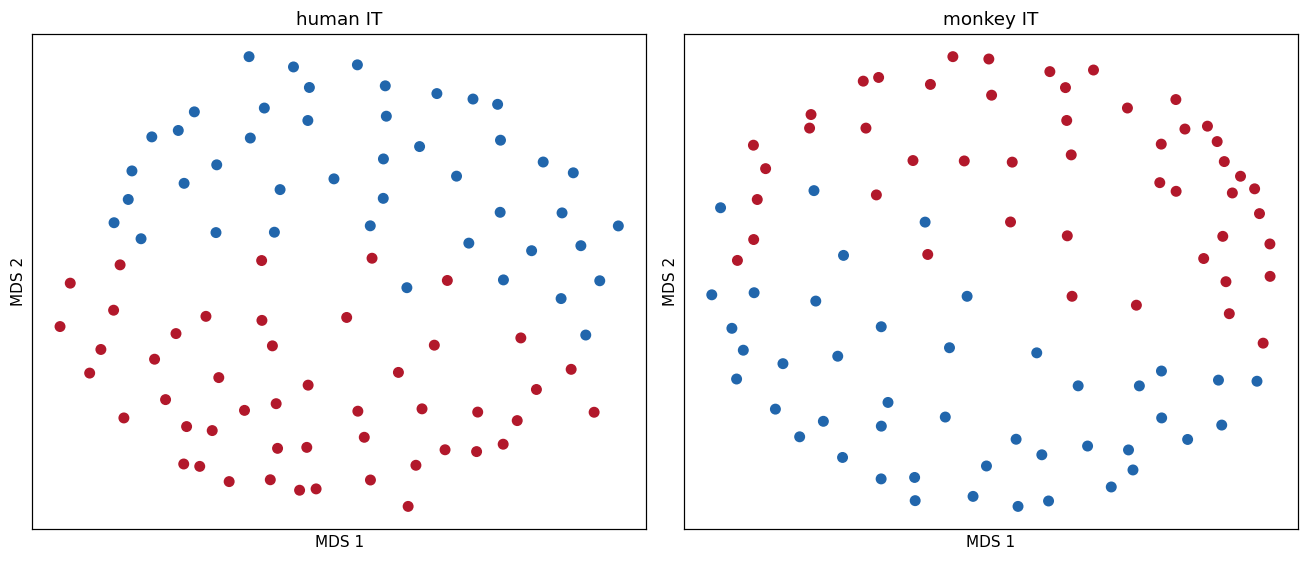

In [13]:
mds_hum = run_mds(hIT_rdm, precomputed=True)
mds_mon = run_mds(mIT_rdm, precomputed=True)

# color by coarse grouping (paper Fig. 2 style)
group = np.where((cat_vec[:, cat_lbls.index('human')] |
                  cat_vec[:, cat_lbls.index('nonhumani')]), '#b2182b',   # animate-ish
                 np.where(cat_vec[:, cat_lbls.index('inanim')], '#2166ac',  # inanimate
                          '#888888'))

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2))
for ax, emb, ttl in [(axes[0], mds_hum, 'human IT'), (axes[1], mds_mon, 'monkey IT')]:
    ax.scatter(emb[:, 0], emb[:, 1], c=group, s=38)
    ax.set(title=ttl, xlabel='MDS 1', ylabel='MDS 2')
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout();

# what do we even gain from MDS here? the RDM *is* the geometry — this just makes it drawable.

Red = animate conditions (human and non-human bodies and faces); blue = inanimate objects. Faces and bodies cluster together, tools separate from them — and the same topology appears in both species, although the data were collected thousands of kilometres apart (human fMRI at NIH in Bethesda; monkey recordings at RIKEN in Japan).

### Exercise 3 — mini-RSA: which model explains human IT?

RSA compares RDMs by correlating their upper triangles. Complete the loop to Spearman-correlate the human-IT RDM against every model RDM plus monkey IT, rank the results, and interpret: which model tracks human IT best? Where does low-level V1 sit relative to IT-style representations — and why is that gap informative?


In [14]:

targets = dict(model_rdms)
targets['monkey IT (this dataset)'] = mIT_rdm
rsa_scores = {}
for name, rdm in targets.items():
    pass  # placeholder so the loop parses; delete it when you uncomment below
    # rsa_scores[name] = spearmanr(hIT_rdm[iu], rdm[iu]).statistic
    # TODO: uncomment the line above — that's the whole exercise. Then:
    # - which model tops the table, and is monkey IT close behind hIT itself?
    # - where do V1/Silhouette (image-level models) land relative to animacy/FaceBody models?

if rsa_scores:
    pd.Series(rsa_scores).sort_values().plot.barh(color='#4C72B0', figsize=(7, 4.5))
    plt.axvline(0, c='k', lw=.6)
    plt.xlabel(r'Spearman $\rho$ with human IT RDM')
    plt.title('Model–brain similarity (mini-RSA)')
else:
    print('(uncomment the statistic line above to produce the ranking)')

(uncomment the statistic line above to produce the ranking)


Note: `hIT_rdm` itself is excluded from `targets` — a matrix correlated with itself returns ρ = 1 trivially. Expected pattern: species and categorical models near the top; low-level image models (Silhouette, V1) near zero.


## 5. Real data II — event structure in experienced sequences: Schapiro et al. 2013

The second data set involves sequences rather than static images. Participants passively viewed long sequences of 15 abstract objects whose transition probabilities followed the graph shown below: three communities (A, B, C) with dense internal connectivity, linked by rare "bridge" transitions. The question is whether the brain comes to treat items experienced in the same temporal context as belonging to the same event.

The paper reports that neural activity patterns reflect this community structure, and the authors made their data public on OpenNeuro [ds001621](https://openneuro.org/datasets/ds001621).


**The experiment's temporal community structure** (Schapiro et al., 2013, Fig. 1). (a) Transition graph: three communities of five objects, joined into one sequence by rare "bridge" links between boundary nodes (lighter shading). (b) The 15 abstract objects. (c) Texture versions of the same objects. The ringed nodes in the embeddings below are the boundary items.

![Transition graph and stimuli, Schapiro et al. 2013, Fig. 1](https://raw.githubusercontent.com/qihongl/NS5007/main/data/schapiro2013_fig1.jpg)

*Figure © Schapiro et al. (2013), reproduced here for classroom use.*


In [15]:
# The packaged fMRI patterns (~15 MB) live in the course GitHub repo.
# This cell fetches whatever is missing and caches it next to the notebook
# (skips files already present, so it runs instantly after the first time).
import os, urllib.request

RAW = 'https://raw.githubusercontent.com/qihongl/NS5007/main/data'
os.makedirs('data', exist_ok=True)
for fname in ['week5_schapiro_patterns.npz', 'week5_schapiro_tmap.npz',
              'week5_schapiro_shifts.npz', 'week5_schapiro_tmap_clusters.json']:
    dest = f'data/{fname}'
    if os.path.exists(dest):
        continue
    url = f'{RAW}/{fname}'
    print('downloading', fname, '...')
    try:
        urllib.request.urlretrieve(url, dest)
    except Exception as e:
        print(f'  !! could not fetch {fname} ({e}).\n'
              f'  !! Upload the data/ folder manually, or check that the '
              f'course GitHub repo exists and RAW points to it.')
for fname in ['week5_schapiro_patterns.npz', 'week5_schapiro_tmap.npz',
              'week5_schapiro_shifts.npz', 'week5_schapiro_tmap_clusters.json']:
    status = 'ok' if os.path.exists(f'data/{fname}') else 'MISSING'
    print(f'  {status:7s} data/{fname}')
print('data ready')

  ok      data/week5_schapiro_patterns.npz
  ok      data/week5_schapiro_tmap.npz
  ok      data/week5_schapiro_shifts.npz
  ok      data/week5_schapiro_tmap_clusters.json
data ready


### Step 1 — load the packaged data

`data/week5_schapiro_patterns.npz` holds, for each of the 20 participants and
4 regions, the 15 × voxel pattern matrix exactly as the paper's recipe
produces it: z-scored timecourse sampled 4 s after onset, Hamiltonian-block
trials only, averaged per item. Motion correction, despiking and
normalization were applied offline — `make_week5_derived_data.py` in the
course folder documents every step against the raw OpenNeuro ds001621 data.


In [16]:
D = np.load('data/week5_schapiro_patterns.npz')
subjects = [str(s) for s in D['subjects']]
nodes    = [str(n) for n in D['nodes']]
regions  = [str(r) for r in D['regions']]
comm     = np.array([n[0] for n in nodes])            # 'A'/'B'/'C'
print('regions:', regions)
print('subjects:', len(subjects))
P_ex = D[f'IFG_insula_L__{subjects[0]}']
print(f'IFG_insula_L__{subjects[0]} ->', P_ex.shape, '(items x voxels)')

regions: ['IFG_insula_L', 'OccTemp_L', 'Hippocampus', 'VisualControl']
subjects: 20
IFG_insula_L__sub-01 -> (15, 512) (items x voxels)


Regions:
- **IFG_insula_L** — left inferior frontal gyrus / anterior insula (MNI ≈ [-43, 27, 11]); the main cluster reported in the paper.
- **OccTemp_L** — left occipito-temporal cortex (MNI ≈ [-25, -80, -10]); the strongest cluster in our whole-brain map.
- **Hippocampus** — bilateral. Although the hippocampus is a natural candidate for event representations, the 2013 paper found **no** pattern effect there; that result comes from the later Schapiro et al. (2016, *Hippocampus*) study.
- **VisualControl** — intracalcarine cortex (V1). Random abstract pictures should not acquire community structure here, so this region serves as a control for artifacts.

### Step 2 — a naive statistic, and why it is misleading

For each item pair we have a similarity (Pearson correlation across voxels, Fisher z-transformed). The naive test of the paper's claim is: same-community pairs should be more similar than different-community pairs. We compute this difference for every subject and region — the results will look convincing. The next step explains why they are not.


In [17]:
from scipy.stats import ttest_1samp

def rdm_fisher(P):
    '''Item-item Pearson correlation, Fisher z-transformed.'''
    M = P - P.mean(axis=1, keepdims=True)
    sd = M.std(axis=1, keepdims=True); sd[sd == 0] = 1
    R = (M / sd) @ (M / sd).T / P.shape[1]
    Fz = np.arctanh(np.clip(R, -0.999, 0.999))
    return (Fz + Fz.T) / 2

iu   = np.triu_indices(15, 1)
same = comm[iu[0]] == comm[iu[1]]

def naive_stat(P):
    Fz = rdm_fisher(P); d = Fz[iu]
    return d[same].mean() - d[~same].mean()

rows = []
for r in regions:
    st = [naive_stat(D[f'{r}__{s}']) for s in subjects]
    st = np.array(st)
    t, pv = ttest_1samp(st, 0)
    rows.append((r, st.mean(), t, pv))
    print(f'{r:14s} naive = {st.mean():+.4f}  t({len(st)-1})={t:5.2f}  p={pv:.2g}  '
          f'positive {int((st > 0).sum())}/{len(st)}')
naive_df = pd.DataFrame(rows, columns=['region', 'naive', 't', 'p']).set_index('region')

IFG_insula_L   naive = +0.1372  t(19)= 8.47  p=7.1e-08  positive 20/20
OccTemp_L      naive = +0.1225  t(19)= 6.62  p=2.5e-06  positive 20/20
Hippocampus    naive = +0.1154  t(19)=13.36  p=4.2e-11  positive 20/20
VisualControl  naive = +0.1108  t(19)=14.29  p=1.3e-11  positive 20/20


Every region — including V1 — shows a "significant" community effect. Random abstract pictures cannot acquire community structure in V1, so a non-representational factor must be contributing.

That factor is **temporal proximity**. In the stimulus sequences, items from the same community occur closer together in time than items from different communities (this is what community structure means for a sequence), and BOLD signals are autocorrelated: two samples close in time share low-frequency drift, habituation, and arousal fluctuations regardless of which objects they represent.

### Step 3 — the paper's control: lag matching

The paper's control is to compare only within- vs. between-community pairs that are the **same number of steps apart** along the subject's fixed Hamiltonian path (1–4 steps; distances of 5+ cannot occur within a 5-node community), and then average. This matches the time-gap distributions of the two pair types, and each item enters exactly four within-community comparisons at these lags (a 5-node community spans at most 4 path steps).

Each subject's Hamiltonian path is packaged as `pathpos__<subject>` (position of each node, 1–15). Implement the lag-matched statistic:


In [18]:
def lag_matched_stat(P, pathpos):
    Fz = rdm_fisher(P); d = Fz[iu]
    dist = np.abs(pathpos[iu[0]] - pathpos[iu[1]])
    ws, bs = [], []
    for dd in (1, 2, 3, 4):                       # 5+ steps: no within pairs
        m = dist == dd
        ws.append(d[m & same].mean())
        bs.append(d[m & ~same].mean())
    return np.mean(ws) - np.mean(bs)

shifts = np.load('data/week5_schapiro_shifts.npz')   # path positions + shift nulls

lag = {r: np.array([lag_matched_stat(D[f'{r}__{s}'], shifts[f'pathpos__{s}'])
                    for s in subjects]) for r in regions}

for r in regions:
    t, pv = ttest_1samp(lag[r], 0)
    print(f'{r:14s} lag-matched = {lag[r].mean():+.4f}  t({len(subjects)-1})={t:5.2f}  p={pv:.3g}  '
          f'positive {int((lag[r] > 0).sum())}/{len(subjects)}')

IFG_insula_L   lag-matched = +0.0632  t(19)= 2.79  p=0.0118  positive 15/20
OccTemp_L      lag-matched = +0.0729  t(19)= 5.36  p=3.55e-05  positive 19/20
Hippocampus    lag-matched = +0.0185  t(19)= 1.68  p=0.11  positive 13/20
VisualControl  lag-matched = +0.0123  t(19)= 1.13  p=0.272  positive 11/20


Compare with Step 2: lag matching reduces every region — by ≈2× in the two cortical regions, and by 6–9× in hippocampus and visual cortex, whose lag-matched values are near zero. Most of the naive effect was temporal proximity.

One question remains: does what *survives* lag matching reflect community representation, or could residual temporal structure still favor within-community pairs? A stricter control is the **shift predictor**: recompute the statistic after circularly shifting each voxel's timecourse by a random offset. Circular shifting preserves the autocorrelation structure exactly while destroying the correspondence between items and sampling times. An effect that survives this procedure is unlikely to be a timing artifact.


,mean,t,p
IFG_insula_L,-0.017453,-1.133776,0.270992
OccTemp_L,0.016095,1.121709,0.280857
Hippocampus,0.010252,1.309584,0.205952
VisualControl,-0.005977,-0.293147,0.772762


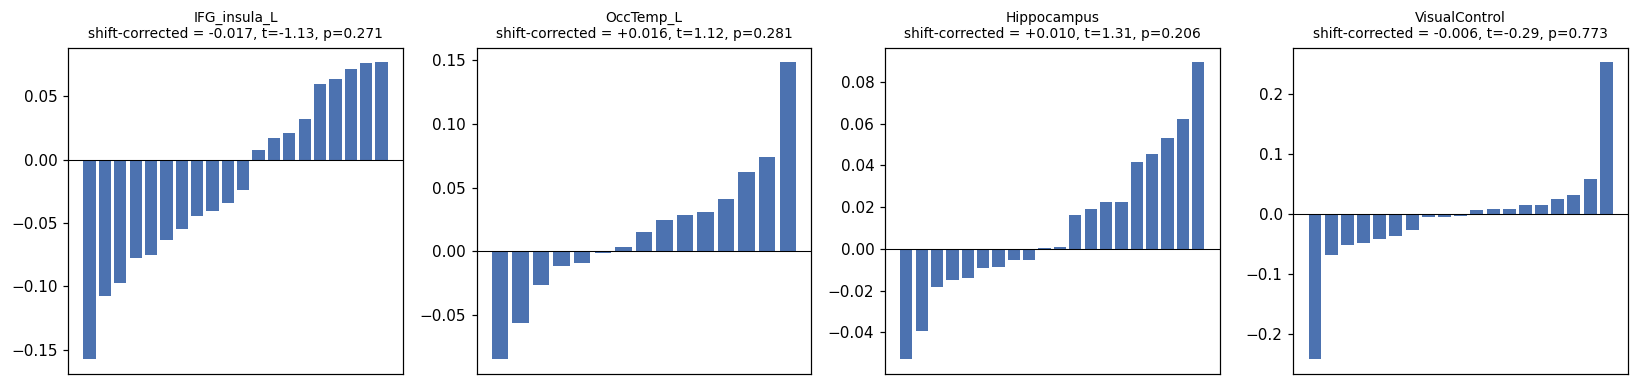

In [19]:
# packaged shift-predictor nulls: 12 random circular shifts per subject/region
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
shift_corr = {}
for ax, r in zip(axes, regions):
    obs  = shifts[f'obsnat__{r}']
    null = shifts[f'shiftnull__{r}']
    corr = obs - null.mean(axis=1)
    okm  = np.isfinite(corr)
    t, pv = ttest_1samp(corr[okm], 0)
    shift_corr[r] = (corr[okm].mean(), t, pv)
    ax.bar(range(okm.sum()), np.sort(corr[okm]), color='#4C72B0')
    ax.axhline(0, c='k', lw=.7)
    ax.set_title(f'{r}\nshift-corrected = {np.nanmean(corr):+.3f}, '
                 f't={t:.2f}, p={pv:.3f}', fontsize=9)
    ax.set_xticks([])
plt.tight_layout();
shift_corr_df = pd.DataFrame(shift_corr, index=['mean', 't', 'p']).T
shift_corr_df

This table is the most important result of the lab.

Read the two controls together. With lag matching alone, the effect remains significant in the two cortical regions (IFG p ≈ .01; occipito-temporal p < 10⁻⁴) and in no other region. The stricter shift predictor removes what remains in *every* region — all hover near zero, and IFG is slightly negative. The summary of our re-analysis: cortical regions retain a small positive lag-matched effect, but no region passes the shift-predictor test with this lighter preprocessing.

The original paper, using a full SPM/AFNI preprocessing pipeline and the same 20 subjects, reported t(19) = 140 for this contrast. Our estimates are far smaller, indicating that the detectable effect depends strongly on preprocessing quality. This is a realistic picture of replication in fMRI RSA: the same direction and the same regions, with much smaller, preprocessing-sensitive magnitudes — and the controls determining how much survives.

### Step 4 — reproduce Figure 4: the group embedding

Average each region's Fisher-z RDM across the 20 subjects, embed with classical MDS (§3), and color by community:


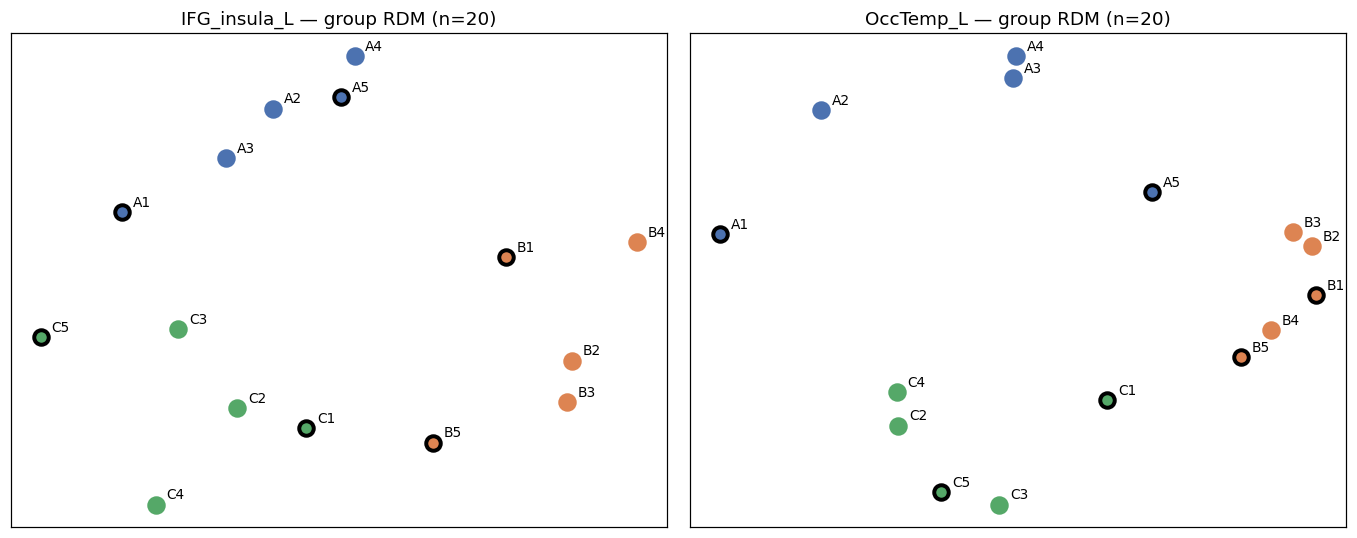

In [20]:
def group_rdm(region):
    return np.nanmean([rdm_fisher(D[f'{region}__{s}']) for s in subjects], axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5))
for ax, r in zip(axes, ['IFG_insula_L', 'OccTemp_L']):
    rG = group_rdm(r)
    rG = (rG + rG.T) / 2; np.fill_diagonal(rG, 0)
    Dm = rG.max() - rG; Dm = (Dm + Dm.T) / 2; np.fill_diagonal(Dm, 0)
    emb = classical_mds(Dm, 2)
    plot_embedding(emb, nodes, title=f'{r} — group RDM (n=20)', ax=ax)
plt.tight_layout();

In both left IFG/insula and occipito-temporal cortex, the three communities form distinguishable sectors, and the boundary nodes (black rings) tend to lie between them — the geometry reported in the paper.

### Step 5 — where in the brain? The whole-brain map

Our whole-brain searchlight t-map (lag-matched statistic, 20 subjects) is also packaged. Find the clusters and compare them against Table 1 of the paper:


In [21]:
from scipy import ndimage

tz = np.load('data/week5_schapiro_tmap.npz')
tmap, taff = tz['tmap'], tz['affine']
lab_img, ncl = ndimage.label(tmap > 3.0)
sizes = ndimage.sum(tmap > 3.0, lab_img, range(1, ncl + 1))
order = np.argsort(sizes)[::-1]

print('top clusters (one-sample t across 20 subjects, lag-matched statistic):')
for rank, k in enumerate(order[:5], 1):
    cmask = lab_img == k + 1
    vox = np.array(np.nonzero(cmask)).T
    peak = taff[:3, :3] @ vox[np.argmax(tmap[cmask])].T + taff[:3, 3]
    print(f'  cluster {rank}: {int(sizes[k]):4d} voxels, peak MNI '
          f'[{peak[0]:.0f}, {peak[1]:.0f}, {peak[2]:.0f}]')

print()
print('paper Table 1 (pattern analysis):')
print('  Left IFG, insula and ATL:  [-40, 11, -6], 150 vox')
print('  Left STG:                  [-53, -23, -1], 107 vox')
print('  (their other analyses: mPFC boundary effect [-1, 44, 17];')
print('   IFG/insula + cuneus adaptation effects)')

top clusters (one-sample t across 20 subjects, lag-matched statistic):
  cluster 1: 1192 voxels, peak MNI [-25, -80, -10]
  cluster 2:  819 voxels, peak MNI [-62, -10, 14]
  cluster 3:  581 voxels, peak MNI [-43, 27, 11]
  cluster 4:  548 voxels, peak MNI [2, 59, -2]
  cluster 5:  498 voxels, peak MNI [-23, -73, 49]

paper Table 1 (pattern analysis):
  Left IFG, insula and ATL:  [-40, 11, -6], 150 vox
  Left STG:                  [-53, -23, -1], 107 vox
  (their other analyses: mPFC boundary effect [-1, 44, 17];
   IFG/insula + cuneus adaptation effects)


### Exercise 4 (challenge) — is the group effect real?

The group IFG embedding looks convincing, but a single statistic can also arise by chance. Run a label-permutation test: shuffle which items belong to community A/B/C (keeping 5 per community), recompute the lag-matched group statistic 500 times, and compute an exact p-value. Note the resolution limit: with 500 permutations the smallest reportable p is 1/501 ≈ .002. Bonus: run the same test on the OccTemp_L group RDM — and on VisualControl, where a real effect should *not* appear (region specificity).


In [22]:
# 500 community-label permutations of the group statistic
rng_perm = np.random.default_rng(1)

def lag_from_fz(Fz, pp):
    d = Fz[iu]
    dist = np.abs(pp[iu[0]] - pp[iu[1]])
    ws, bs = [], []
    for dd in (1, 2, 3, 4):
        m = dist == dd
        ws.append(d[m & same].mean()); bs.append(d[m & ~same].mean())
    return np.mean(ws) - np.mean(bs)

# One approximation, stated so you see it: the group RDM pools subjects, but each
# subject followed their own Hamiltonian path -- we lag-match the pooled RDM with
# one subject's path (sub-16). The exact version is Step 3 (per-subject statistics
# with their own paths); the two agree closely here.
for region in ['IFG_insula_L', 'OccTemp_L', 'VisualControl']:
    G = np.nanmean([rdm_fisher(D[f'{region}__{s}']) for s in subjects], axis=0)
    obs = lag_from_fz(G, shifts['pathpos__sub-16'])
    null = []
    for _ in range(500):
        perm = rng_perm.permutation(15)
        null.append(lag_from_fz(G[np.ix_(perm, perm)], shifts['pathpos__sub-16']))
    p_perm = (np.sum(np.array(null) >= obs) + 1) / 501
    print(f'{region:14s} observed = {obs:+.4f}, permutation p = {p_perm:.3f}')


IFG_insula_L   observed = +0.0568, permutation p = 0.034
OccTemp_L      observed = +0.0675, permutation p = 0.008
VisualControl  observed = +0.0062, permutation p = 0.355


## 6. Wrap-up

| | **PCA** | **MDS** |
|---|---|---|
| input | data matrix (N conditions × features) | distance/RDM matrix (N × N) |
| finds | directions of maximal variance | coordinates preserving pairwise distances |
| interpretable output | loadings: feature weights per PC | geometry only |
| typical failure | curved surfaces fold flat; scaling/outliers dominate distances | relative structure only, no feature meaning |

Neither method is sensitive to what matters for your question: high variance does not imply informative variation. Where that matters, supervised extensions exist (CVA, classification-based RSA) — beyond the scope of this lab.

**Summary.** In this lab you implemented PCA and classical MDS from scratch, reproduced the cross-species IT RDMs of Kriegeskorte et al. (2008), built RDMs from real fMRI patterns, implemented the lag-matching control and shift predictor of Schapiro et al. (2013), and reproduced their community embedding — while seeing how controls determine whether a correlation means what it appears to mean.

### Glossary
- **RDM** — representational dissimilarity matrix; N×N distances between activity patterns.
- **RSA** — comparing RDMs (regions, species, models) by correlating their entries.
- **Scree plot** — variance explained per PC; the elbow suggests how many components matter.
- **Classical (Torgerson) MDS** — eigendecomposition of a doubly-centered squared-distance matrix; scikit-learn's `MDS` is the iterative stress-minimizing (SMACOF) variant.
- **Isomap** — MDS on geodesic (along-surface) distances; unrolls curved surfaces that linear projections fold.
- **events.tsv** — BIDS table of stimulus onsets/durations that anchors GLM regressors to the actual experiment.

### References & credits
- Kriegeskorte, N., Mur, M., Ruff, D., Kiani, R., Bodurka, J., Esteky, H., Tanaka, K., Bandettini, P. (2008). Matching categorical object representations in inferior temporal cortex of man and monkey. *Neuron*. Data © the authors, mirrored via [rsatoolbox](https://github.com/rsagroup/rsatoolbox).
- Derived fMRI patterns: generated from OpenNeuro ds001621 by `make_week5_derived_data.py` (despiking, rigid motion correction, affine MNI normalization, item-pattern extraction per the 2013 Methods). The 2013 searchlight clusters are cortical (left IFG/insula, ATL, STG); hippocampal event representations come from the 2016 *Hippocampus* follow-up.
- Schapiro, A. C., Rogers, T. T., Cordova, N. I., Turk-Browne, N. B., & Botvinick, M. M. (2013). Neural representations of events arise from temporal community structure. *Nature Neuroscience*, 16, 486–492, doi:[10.1038/nn.3331](https://doi.org/10.1038/nn.3331). Figure 1 reproduced for classroom use. Data: OpenNeuro [ds001621](https://openneuro.org/datasets/ds001621).
- Tools: numpy / scipy / matplotlib / scikit-learn; Harvard–Oxford atlas (FSL).


---

## Solutions

Each solution expands below. Compare it with your own attempt — different parameter values can be equally correct.


<details><summary><b>Exercise 1</b></summary>

```python
var_first_two = pca.explained_variance_ratio_[:2].sum()   # ~92%

pcs_2d  = pca.transform(X_blob)[:, :2]
D_after = pdist(pcs_2d)
np.corrcoef(D_before, D_after)[0, 1]     # ≈ 0.99+: geometry essentially intact after 10 -> 2 dims
```
</details>

<details><summary><b>Exercise 2</b></summary>

```python
within_f, between_f = rdm_within_between(hIT_rdm, mask_face)
# faces are MORE similar to each other than to everything else;
# if categories were irrelevant both numbers would equal the grand mean (≈ 0.85 here).
```
</details>

<details><summary><b>Exercise 3</b></summary>

```python
for name, rdm in targets.items():
    rsa_scores[name] = spearmanr(hIT_rdm[iu], rdm[iu]).statistic
pd.Series(rsa_scores).sort_values().plot.barh()
# Expected: animacy & FaceBodyManmadeNatobj up top; monkey IT strong; Silhouette/V1 near zero.
```
</details>

<details><summary><b>Exercise 4</b></summary>

```python
# same loop as the cell above, pointed at each region's group RDM
# Expected on the shipped data (deterministic given the seed): IFG_insula_L
# p ≈ .03, OccTemp_L p ≈ .008 -- real but unimpressive, the preprocessing-
# sensitive effect sizes discussed in Step 3 -- and VisualControl at chance
# (p ≈ .36): the effect is not region-specific once you look in visual cortex.
# With 500 permutations the smallest reportable p is 1/501 ≈ .002, so a fitted
# 'p < .001' is not a sentence this test can produce.
```
</details>
